# 지도학습 - 회귀 (통합 데이터: 시설물 + 구조 위험)

## 1) 라이브러리 및 데이터 불러오기

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, recall_score, f1_score, classification_report
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False


In [9]:
df_train_full = pd.read_csv('./data/seongnam_train.csv', encoding='utf-8-sig')
df_test_final = pd.read_csv('./data/seongnam_test.csv', encoding='utf-8-sig')

print(f"Train 원본: {df_train_full.shape[0]}행 x {df_train_full.shape[1]}열")
print(f"Test  원본: {df_test_final.shape[0]}행 x {df_test_final.shape[1]}열")
print(f"\n컬럼: {df_train_full.columns.tolist()}")


Train 원본: 110행 x 15열
Test  원본: 32행 x 15열

컬럼: ['시설물명', '위도', '경도', '도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라', '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도', '어린이 비율(%)', '발생건수', 'structure_risk']


In [10]:
LABEL = '발생건수'
DROP  = ['시설물명', '위도', '경도', 'structure_risk', LABEL]


STEP 1 | 데이터 기본 탐색 (train.csv)
데이터 크기: 110행 x 15열

결측치:
없음

기술통계:
            위도       경도   도로안전표지   도로적색표면  무단횡단방지펜스  무인교통단속카메라  보호구역표지판  생활안전CCTV      신호등     옐로카펫     횡단보도  어린이 비율(%)     발생건수  structure_risk
count  110.000  110.000  110.000  110.000   110.000    110.000  110.000   110.000  110.000  110.000  110.000    110.000  110.000         110.000
mean    37.411  127.133    0.056    0.023    -0.042     -0.063   -0.003     0.092    0.006    0.008    0.060     -0.036    0.164           0.000
std      0.037    0.023    1.002    1.005     1.026      1.036    1.057     1.014    1.033    1.071    0.992      1.025    0.684           1.005
min     37.338  127.069   -1.481   -1.622    -1.698     -1.745   -4.300    -2.908   -1.552   -1.457   -1.543     -1.646    0.000          -1.909
25%     37.375  127.118   -0.664   -0.603    -0.868     -0.500   -0.482    -0.542   -0.666   -1.457   -0.713     -0.883    0.000          -0.796
50%     37.410  127.133    0.152   -0.263    -0.239      0.228  

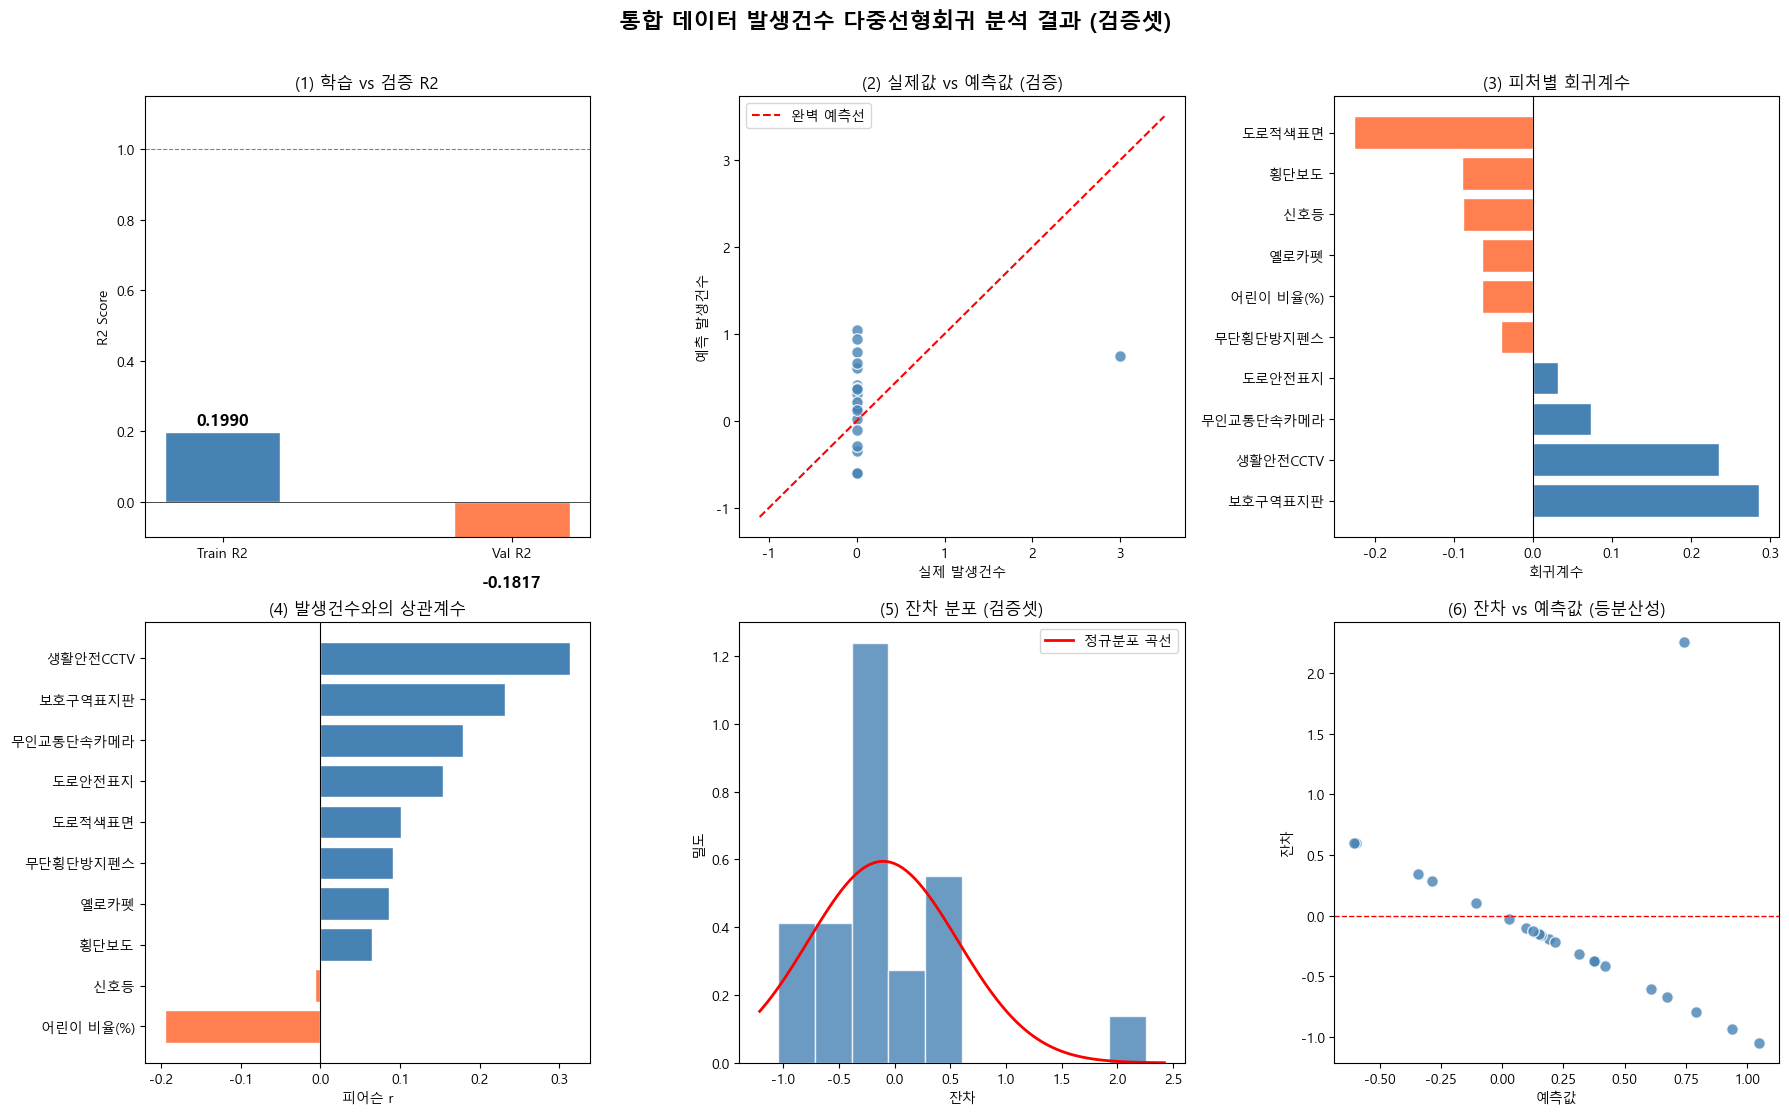


검증셋 시각화 저장 완료: regression_integrated_val.png


In [11]:
df = df_train_full.copy()

# ═══════════════════════════════════════════════════════════════════
# STEP 1 ── 데이터 기본 탐색
# ═══════════════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 1 | 데이터 기본 탐색 (train.csv)")
print("=" * 60)
print(f"데이터 크기: {df.shape[0]}행 x {df.shape[1]}열")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"\n결측치:\n{missing.to_string() if len(missing) > 0 else '없음'}")
print(f"\n기술통계:\n{df.describe().round(3).to_string()}")

X_raw    = df.drop(columns=DROP)
y        = df[LABEL]
features = X_raw.columns.tolist()
print(f"\n사용 피처 ({len(features)}개): {features}")
print(f"레이블 분포 - min:{y.min():.1f}  max:{y.max():.1f}  mean:{y.mean():.4f}  std:{y.std():.4f}")
print(f"\n발생건수 값 분포:\n{y.value_counts().sort_index().to_string()}")

# ═══════════════════════════════════════════════════════════════════
# STEP 2 ── 상관관계 분석
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2 | 상관관계 분석 (피어슨 r)")
print("=" * 60)

corr_with_label = X_raw.apply(lambda col: col.corr(y))
corr_df = corr_with_label.sort_values(ascending=False).to_frame(name='r')
corr_df['|r|'] = corr_df['r'].abs()
print(corr_df.round(4).to_string())

# ═══════════════════════════════════════════════════════════════════
# STEP 3 ── 다중공선성 검사 (VIF)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3 | 다중공선성 검사 (VIF)")
print("=" * 60)

scaler_vif   = StandardScaler()
X_scaled_vif = scaler_vif.fit_transform(X_raw)

vif_data = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(X_scaled_vif, i)
            for i in range(X_scaled_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.round(2).to_string(index=False))
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
if high_vif:
    print(f"\nVIF > 10 (다중공선성 의심): {high_vif}")
else:
    print("\n심각한 다중공선성 없음 (모두 VIF <= 10)")

# ═══════════════════════════════════════════════════════════════════
# STEP 4 ── 모델 학습 (train.csv → 80:20 학습/검증)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4 | 모델 학습 (train.csv 80:20 분할)")
print("=" * 60)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

model = LinearRegression()
model.fit(X_tr_s, y_tr)

y_pred_tr  = model.predict(X_tr_s)
y_pred_val = model.predict(X_val_s)

print(f"학습 샘플: {len(X_tr)}  |  검증 샘플: {len(X_val)}")
print(f"절편 (intercept): {model.intercept_:.4f}")

coef_df = pd.DataFrame({
    'Feature': features,
    'Coef': model.coef_
}).sort_values('Coef', ascending=False)
print(f"\n회귀계수:\n{coef_df.round(4).to_string(index=False)}")

# ═══════════════════════════════════════════════════════════════════
# STEP 5 ── 회귀 지표 (검증셋)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5 | 회귀 지표 (검증셋)")
print("=" * 60)

tr_r2    = r2_score(y_tr,  y_pred_tr)
val_r2   = r2_score(y_val, y_pred_val)
tr_mae   = mean_absolute_error(y_tr,  y_pred_tr)
val_mae  = mean_absolute_error(y_val, y_pred_val)
tr_rmse  = np.sqrt(mean_squared_error(y_tr,  y_pred_tr))
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))

metrics_val = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'RMSE'],
    'Train':  [tr_r2,   tr_mae,  tr_rmse],
    'Val':    [val_r2,  val_mae, val_rmse],
})
print(metrics_val.round(4).to_string(index=False))
print(f"\n과적합 지수 (Train R2 - Val R2): {(tr_r2 - val_r2):.4f}")

# ═══════════════════════════════════════════════════════════════════
# STEP 6 ── 분류 지표 (이진 이산화: 없음/있음)
# 발생건수 데이터 특성 (값: 0 또는 3) → 0건 vs 1건 이상 이진 분류
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6 | 분류 지표 (이진: 없음·있음)")
print("=" * 60)

BINS        = [float('-inf'), 0.5, float('inf')]
LABELS_CLS  = [0, 1]
CLASS_NAMES = ['없음(0건)', '있음(1건~)']

def to_cls(s):
    return pd.cut(pd.Series(s).reset_index(drop=True),
                  bins=BINS, labels=LABELS_CLS).astype(int).values

y_val_cls  = to_cls(y_val)
y_pred_cls = to_cls(y_pred_val)

print(f"Accuracy : {accuracy_score(y_val_cls, y_pred_cls):.4f}")
print(f"Recall   : {recall_score(y_val_cls, y_pred_cls, average='macro', zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_val_cls, y_pred_cls, average='macro', zero_division=0):.4f}")
print(f"\n분류 리포트:\n{classification_report(y_val_cls, y_pred_cls, target_names=CLASS_NAMES, zero_division=0)}")

# ═══════════════════════════════════════════════════════════════════
# STEP 7 ── 잔차 분석 (검증셋)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 7 | 잔차 분석 (검증셋)")
print("=" * 60)

residuals = y_val.values - y_pred_val
stat, p_value = stats.shapiro(residuals)
print(f"Shapiro-Wilk 검정 - W={stat:.4f}, p={p_value:.4f}")
print("잔차 정규성:", "만족 (p > 0.05)" if p_value > 0.05 else "불만족 (p <= 0.05)")
print(f"잔차 평균: {residuals.mean():.4f}  |  잔차 표준편차: {residuals.std():.4f}")

# ═══════════════════════════════════════════════════════════════════
# STEP 8 ── 시각화 (6개 패널, 검증셋 기준)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('통합 데이터 발생건수 다중선형회귀 분석 결과 (검증셋)', fontsize=16, fontweight='bold', y=1.01)

# (1) 학습 vs 검증 R²
ax = axes[0, 0]
bars = ax.bar(['Train R2', 'Val R2'], [tr_r2, val_r2],
               color=['steelblue', 'coral'], width=0.4, edgecolor='white')
ax.set_ylim(-0.1, 1.15)
ax.set_ylabel('R2 Score')
ax.set_title('(1) 학습 vs 검증 R2')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(0.0, color='black', linestyle='-', linewidth=0.5)
for bar, v in zip(bars, [tr_r2, val_r2]):
    ypos = bar.get_height() + 0.02 if bar.get_height() >= 0 else bar.get_height() - 0.06
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# (2) 실제값 vs 예측값
ax = axes[0, 1]
ax.scatter(y_val, y_pred_val, alpha=0.8, color='steelblue', edgecolors='white', s=70)
mn = min(float(y_val.min()), float(y_pred_val.min())) - 0.5
mx = max(float(y_val.max()), float(y_pred_val.max())) + 0.5
ax.plot([mn, mx], [mn, mx], 'r--', label='완벽 예측선')
ax.set_xlabel('실제 발생건수')
ax.set_ylabel('예측 발생건수')
ax.set_title('(2) 실제값 vs 예측값 (검증)')
ax.legend()

# (3) 피처별 회귀계수
ax = axes[0, 2]
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coef']]
ax.barh(coef_df['Feature'], coef_df['Coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('회귀계수')
ax.set_title('(3) 피처별 회귀계수')

# (4) 상관계수
ax = axes[1, 0]
sorted_corr = corr_df.sort_values('r')
ax.barh(sorted_corr.index, sorted_corr['r'],
        color=['coral' if v < 0 else 'steelblue' for v in sorted_corr['r']],
        edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('피어슨 r')
ax.set_title('(4) 발생건수와의 상관계수')

# (5) 잔차 분포
ax = axes[1, 1]
ax.hist(residuals, bins=10, color='steelblue', edgecolor='white', density=True, alpha=0.8)
xmin, xmax = ax.get_xlim()
x_range = np.linspace(xmin, xmax, 100)
ax.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
        'r-', linewidth=2, label='정규분포 곡선')
ax.set_xlabel('잔차')
ax.set_ylabel('밀도')
ax.set_title('(5) 잔차 분포 (검증셋)')
ax.legend()

# (6) 잔차 vs 예측값
ax = axes[1, 2]
ax.scatter(y_pred_val, residuals, alpha=0.8, color='steelblue', edgecolors='white', s=70)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('예측값')
ax.set_ylabel('잔차')
ax.set_title('(6) 잔차 vs 예측값 (등분산성)')

plt.tight_layout()
plt.savefig('./data/regression_integrated_val.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n검증셋 시각화 저장 완료: regression_integrated_val.png")


## STEP 9 | 최종 테스트 (seongnam_test.csv)

STEP 9 | 최종 테스트 (seongnam_test.csv)
테스트 샘플: 32

[회귀 지표]
  R2   : 0.0821
  MAE  : 0.3713
  RMSE : 0.6957

[분류 지표 (이진: 없음·있음)]
  Accuracy : 0.9062
  Recall   : 0.7167
  F1-Score : 0.6746

분류 리포트:
              precision    recall  f1-score   support

      없음(0건)       0.97      0.93      0.95        30
     있음(1건~)       0.33      0.50      0.40         2

    accuracy                           0.91        32
   macro avg       0.65      0.72      0.67        32
weighted avg       0.93      0.91      0.91        32

[잔차 분석]
  Shapiro-Wilk - W=0.6322, p=0.0000
  잔차 정규성: 불만족 (p <= 0.05)
  잔차 평균: 0.0497  |  잔차 표준편차: 0.6940

성능 비교 요약
Metric  Train     Val   Test
    R2 0.1990 -0.1817 0.0821
   MAE 0.3706  0.4859 0.3713
  RMSE 0.6216  0.6793 0.6957


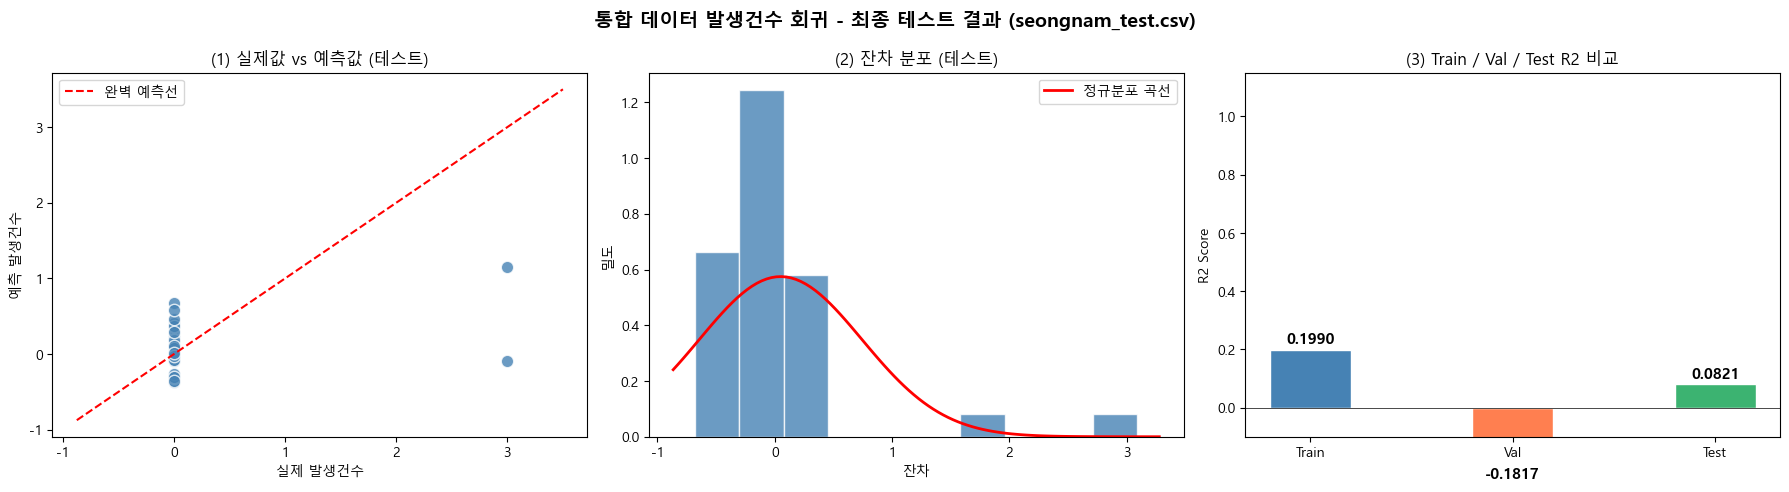


테스트셋 시각화 저장 완료: regression_integrated_test.png


In [12]:
print("=" * 60)
print("STEP 9 | 최종 테스트 (seongnam_test.csv)")
print("=" * 60)

X_test_final = df_test_final.drop(columns=DROP)
y_test_final = df_test_final[LABEL]

# train.csv로 fit된 scaler + model 그대로 사용
X_test_final_s = scaler.transform(X_test_final)
y_pred_final   = model.predict(X_test_final_s)

print(f"테스트 샘플: {len(X_test_final)}")

final_r2   = r2_score(y_test_final, y_pred_final)
final_mae  = mean_absolute_error(y_test_final, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))

print("\n[회귀 지표]")
print(f"  R2   : {final_r2:.4f}")
print(f"  MAE  : {final_mae:.4f}")
print(f"  RMSE : {final_rmse:.4f}")

y_test_cls_final = to_cls(y_test_final)
y_pred_cls_final = to_cls(y_pred_final)

print("\n[분류 지표 (이진: 없음·있음)]")
print(f"  Accuracy : {accuracy_score(y_test_cls_final, y_pred_cls_final):.4f}")
print(f"  Recall   : {recall_score(y_test_cls_final, y_pred_cls_final, average='macro', zero_division=0):.4f}")
print(f"  F1-Score : {f1_score(y_test_cls_final, y_pred_cls_final, average='macro', zero_division=0):.4f}")
print(f"\n분류 리포트:\n{classification_report(y_test_cls_final, y_pred_cls_final, target_names=CLASS_NAMES, zero_division=0)}")

residuals_final = y_test_final.values - y_pred_final
stat_f, p_f = stats.shapiro(residuals_final)
print("[잔차 분석]")
print(f"  Shapiro-Wilk - W={stat_f:.4f}, p={p_f:.4f}")
print("  잔차 정규성:", "만족 (p > 0.05)" if p_f > 0.05 else "불만족 (p <= 0.05)")
print(f"  잔차 평균: {residuals_final.mean():.4f}  |  잔차 표준편차: {residuals_final.std():.4f}")

print("\n" + "=" * 60)
print("성능 비교 요약")
print("=" * 60)
summary = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'RMSE'],
    'Train':  [tr_r2,     tr_mae,     tr_rmse],
    'Val':    [val_r2,    val_mae,    val_rmse],
    'Test':   [final_r2,  final_mae,  final_rmse],
})
print(summary.round(4).to_string(index=False))

# ── 최종 테스트 시각화 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('통합 데이터 발생건수 회귀 - 최종 테스트 결과 (seongnam_test.csv)',
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.scatter(y_test_final, y_pred_final, alpha=0.8, color='steelblue', edgecolors='white', s=80)
mn = min(float(y_test_final.min()), float(y_pred_final.min())) - 0.5
mx = max(float(y_test_final.max()), float(y_pred_final.max())) + 0.5
ax.plot([mn, mx], [mn, mx], 'r--', label='완벽 예측선')
ax.set_xlabel('실제 발생건수')
ax.set_ylabel('예측 발생건수')
ax.set_title('(1) 실제값 vs 예측값 (테스트)')
ax.legend()

ax = axes[1]
ax.hist(residuals_final, bins=10, color='steelblue', edgecolor='white', density=True, alpha=0.8)
xmin, xmax = ax.get_xlim()
x_range = np.linspace(xmin, xmax, 100)
ax.plot(x_range, stats.norm.pdf(x_range, residuals_final.mean(), residuals_final.std()),
        'r-', linewidth=2, label='정규분포 곡선')
ax.set_xlabel('잔차')
ax.set_ylabel('밀도')
ax.set_title('(2) 잔차 분포 (테스트)')
ax.legend()

ax = axes[2]
bars = ax.bar(['Train', 'Val', 'Test'], [tr_r2, val_r2, final_r2],
               color=['steelblue', 'coral', 'mediumseagreen'], width=0.4, edgecolor='white')
ax.set_ylim(-0.1, 1.15)
ax.set_ylabel('R2 Score')
ax.set_title('(3) Train / Val / Test R2 비교')
ax.axhline(0.0, color='black', linestyle='-', linewidth=0.5)
for bar, v in zip(bars, [tr_r2, val_r2, final_r2]):
    ypos = bar.get_height() + 0.02 if bar.get_height() >= 0 else bar.get_height() - 0.06
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('./data/regression_integrated_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n테스트셋 시각화 저장 완료: regression_integrated_test.png")
